# Venn Diagram Construction Script

This notebook builds a 7-set Venn diagram from customer campaign participation data, overlays real counts, and exports the result as a PNG image.

## 1. Setup and Imports

**What we do here:**
- Import all necessary libraries for data processing, geometry, and visualisation
- Add the path to our custom `bezier` library (handles smooth curve construction)

**Why:**
- `psycopg2` — connect to PostgreSQL/Greenplum database
- `pandas` — work with tabular data
- `numpy` — mathematical operations (matrices, vectors)
- `shapely` — geometric operations (intersections, differences)
- `matplotlib` — drawing and exporting the diagram
- `bezier` — our custom library for building smooth splines (Hobby algorithm)


In [1]:
import psycopg2
import pandas as pd
import math
import os
import pathlib
import subprocess
import json
import numpy as np
import shapely.geometry
import shapely.affinity
import matplotlib.pyplot as plt
import sys
import os

#path to bezier.py
notebook_dir = r"C:\Users\polina.shishkina\Desktop\venn7"  
sys.path.append(notebook_dir)

import bezier

Defaulting to user installation because normal site-packages is not writeable


## 2. Database Connection

**What we do here:**
- Establish a secure connection to the corporate data warehouse

In [2]:
# DB Connection
conn = psycopg2.connect(
    host="gdb-dws.ru.rumadm.net",
    port="8000",
    database="rusccp",
    user="rusccp_db_123234345",
    password="8hvMZOaB"
)
conn.autocommit = True

## 3. Define the 7-Set Venn Diagram Class

**What we do here:**

Create the main `VennDiagram` class with the following responsibilities:

1. **Parse matrix encoding string** — a special permutation matrix that determines how petals are ordered to ensure all 127 intersections are visible

2. **Generate a single petal spline** — delegates to `VennDiagramRenderer` (defined later)

3. **Convert spline to polygon** — samples points along the curve for geometric operations

4. **Generate all 7 petals** — rotates the base petal by 0°, 51.4°, 102.8°, etc. (multiples of 2π/7)

5. **Compute all intersection regions** — for each bitmask from 1 to 127:
   - Intersect petals where bit = 1
   - Subtract petals where bit = 0
   - Store non-empty regions as shapely polygons

6. **Render diagram with values** — draws petals, overlays text labels with customer counts, applies manual offsets for tricky cases

**Why separate class:**
- Clean separation of concerns
- Reusable for different datasets
- Easy to extend to 8 or 9 sets


In [3]:
# =====================================================
# VENN DIAGRAM
# =====================================================

class VennDiagram:
    def __init__(self, n, matrix_encoding_string, name=None, renderer_args=None):
        self.name = name
        self.n = n
        self.row_swaps = self.parse_matrix_encoding_string(matrix_encoding_string)
        self.flattened_row_swaps = [y for x in self.row_swaps for y in x]
        self.renderer_args = renderer_args or {}

    def parse_matrix_encoding_string(self, matrix_encoding_string):
        rows = matrix_encoding_string.strip().splitlines()
        matrix = [[int(c) for c in line.strip()] for line in rows]

        row_swaps = []
        for column in range(len(matrix[0])):
            entry = []
            for row in range(len(matrix)):
                if matrix[row][column] == 1:
                    entry.append(row + 1)
            row_swaps.append(entry)
        return row_swaps

    def get_spline(self, index=0):
        renderer = VennDiagramRenderer(self, **self.renderer_args)
        return renderer.get_spline(index)

    def get_polygon(self, index=0, resolution=25):
        spline = self.get_spline(index)
        points = []
        for bezier in spline.beziers:
            for i in range(resolution):
                points.append(bezier(i / resolution))
        return points


    def get_curve_polygons(self):
        base_curve = shapely.geometry.Polygon(self.get_polygon())
        curves = []
        for i in range(self.n):
            angle = 2 * math.pi * i / self.n
            curve = shapely.affinity.rotate(base_curve, angle, origin=(0,0), use_radians=True)
            curves.append(curve)
        return curves

    def get_regions(self):
        curves = self.get_curve_polygons()
        regions = {}
        for rank in range(1, 2 ** self.n):
            included = []
            excluded = []
            tmp = rank
            for i in range(self.n):
                if tmp % 2 == 1:
                    included.append(curves[i])
                else:
                    excluded.append(curves[i])
                tmp //= 2
            region = included[0]
            for poly in included[1:]:
                region = region.intersection(poly)
            for poly in excluded:
                region = region.difference(poly)
            if not region.is_empty:
                regions[rank] = region
        return regions

    def plot_with_values(self, region_counts, min_value_to_show=1, min_fontsize=5):
        curves = self.get_curve_polygons()
        regions = self.get_regions()

        fig, ax = plt.subplots(figsize=(14, 14))

        colors = [
            "#cfe8ff",  # blue
            "#fff0b3",  # light-yellow
            "#d9e2ec",  # grey-blue
            "#b3e5fc",
            "#ffe082",
            "#cfd8dc",
            "#bbdefb"
        ]        
        
        manual_offsets = {
            1 << 0: (0.0, -0.3),   # MP
            1 << 1: (-0.8, -0.8),    # LP
            1 << 2: (0.0, 0.1),   # AG
            1 << 3: (-0.4, 0.4),    # RA
            1 << 4: (1.0, 0.7),   # BD
            1 << 5: (0.1, 0.5),    # TM
            1 << 6: (0.2, -0.6),  # OP
            9:   (0.0, 0.4),   # MP+RA — manually turn higher
            17:  (0.0, -0.45),  # MP+BD — manually turn lower
            63:  (0.0, -0.4),  # MP+LP+AG+RA+BD+TM — manually turn lower
        }

        for i, curve in enumerate(curves):
            x, y = curve.exterior.xy
            ax.fill(x, y, alpha=0.35, color=colors[i % len(colors)])
            ax.plot(x, y, color="gray", linewidth=1)

        for rank, region in regions.items():
            value = region_counts.get(rank, 0)
            if value < min_value_to_show:
                continue

            point = region.representative_point()
            formatted_value = f"{value:,}".replace(",", " ")
            label = mask_to_label(rank)

            # ----------------------------
            # Titles wrapping to a new line
            # ----------------------------
            parts = label.split("+")
            if len(parts) <= 3:
                label_wrapped = "+".join(parts)
            else:
                lines = []
                for i in range(0, len(parts), 3):
                    lines.append("+".join(parts[i:i+3]))
                label_wrapped = "\n".join(lines)

            text = f"{label_wrapped}\n{formatted_value}"

            # ----------------------------
            # Autosizing fonts by region width/height
            # ----------------------------
            minx, miny, maxx, maxy = region.bounds
            width = maxx - minx
            height = maxy - miny
            fontsize = 0.5 * min(width, height)
            fontsize = max(min_fontsize, min(8, fontsize))  # min/max restrictions

            # Applying an offset to the single campaign
            cx, cy = point.x, point.y
            if rank in manual_offsets:
                dx, dy = manual_offsets[rank]
                cx += 5*dx
                cy += 5*dy

            ax.text(
                cx,
                cy,
                text,
                ha="center",
                va="center",
                fontsize=fontsize,
                linespacing=1.2,
                wrap=True
            )

        ax.set_aspect("equal")
        ax.axis("off")
        plt.show()

        return fig

## 4. Define the Venn Diagram Renderer (Petal Geometry Engine)

**What we do here:**

Create `VennDiagramRenderer` — the core geometric engine that builds a single petal using the cylinder unwrapping method.

**Step-by-step logic:**

1. **Cylinder unwrapping** (`_get_curve_points_on_cylinder`)
   - Pretend the petal is cut and unrolled onto a cylinder surface
   - Generate control points with (row, column) coordinates
   - Row = distance from centre, Column = rotation angle

2. **Add arc points** (`_add_arc_points`)
   - Insert intermediate points to smooth the transitions between segments

3. **Compute angles** (`_get_angles`)
   - For each control point, calculate the slope angle
   - Angle = tangential component (follows the circle) + tilt correction (depends on row change)

4. **Convert to polar coordinates** (`_convert_cylinder_points_to_polar`)
   - Transform (row, column) → actual (x, y) coordinates on the plane
   - Uses radius = inner_radius + spacing × row
   - Uses theta = column × 2π / total_columns

5. **Build spline** (using `bezier.AngleSpline`)
   - Takes points and angles, constructs smooth curves between them
   - Each segment becomes a cubic Bézier curve with specified entry/exit angles

6. **Normalise** (`_normalize_rotation_and_scaling`)
   - Rotate and scale the petal so it fits a standard bounding circle
   - Ensures all 7 petals are symmetric when rotated

**Why this approach:**
- Circles fail to produce all intersections for 7 sets
- Custom petal shape designed specifically for 7-fold rotational symmetry
- Cylinder unwrapping is a known technique from differential geometry


In [4]:
# =====================================================
# VENN DIAGRAM RENDERER
# =====================================================

class VennDiagramRenderer:
    def __init__(self, venn_diagram, inner_radius=30, spacing=5, tension_diagonal=1.0, tension_default=1.0, extra_outer_spacing=0):
        self.n = venn_diagram.n
        self.row_swaps = venn_diagram.row_swaps
        self.inner_radius = inner_radius
        self.spacing = spacing
        self.tension_diagonal = tension_diagonal
        self.tension_default = tension_default
        self.extra_outer_spacing = extra_outer_spacing
        self.fudge_factor = 1e-4

    def _get_radius_of_row(self, row, use_extra_outer_spacing=True):
        adjusted_row = row
        if use_extra_outer_spacing:
            if row <= 1:
                adjusted_row -= self.extra_outer_spacing
            if row >= self.n - 1:
                adjusted_row += self.extra_outer_spacing
        return self.inner_radius + self.spacing * adjusted_row

    def _get_curve_points_on_cylinder(self, index):
        points = []
        row, column = 0, index * len(self.row_swaps)
        for _ in range(self.n):
            for swap_rows in self.row_swaps:
                if row + 1 in swap_rows:
                    points.append((row + 1, column, "intersection_+"))
                    row += 1
                elif row in swap_rows:
                    points.append((row, column, "intersection_-"))
                    row -= 1
                column += 1
        return points

    def _add_arc_points(self, points):
        squash_factor = len(self.row_swaps)
        result = []
        for i in range(len(points)):
            r1, c1, type_1 = points[i]
            r2, c2, type_2 = points[(i+1) % len(points)]
            result.append(points[i])
            if r1 == r2:
                radius = (c2 - c1) % len(self.n * self.row_swaps) * 0.5
                column = c1 + radius
                if type_1=="intersection_+" and type_2=="intersection_-":
                    arc_direction=1
                    type_arc="arc_+"
                elif type_1=="intersection_-" and type_2=="intersection_+":
                    arc_direction=-1
                    type_arc="arc_-"
                else:
                    continue
        return result

    def _get_angles(self, cylinder_points):
        result = []
        for row, column, type_ in cylinder_points:
            tangent_angle = 2 * np.pi * column / (self.n * len(self.row_swaps)) + np.pi/2
            angle = tangent_angle
            dy = self.spacing
            dx = self._get_radius_of_row(row) * 2 * np.pi / (self.n*len(self.row_swaps))
            tilt_angle = np.arctan2(dy, dx)
            if type_=="intersection_+":
                angle -= tilt_angle
            elif type_=="intersection_-":
                angle += tilt_angle
            angle = angle % (2*np.pi)
            result.append(angle)
        return result

    def _convert_cylinder_points_to_polar(self, cylinder_points):
        polar_points = []
        for row, column, __ in cylinder_points:
            radius = self._get_radius_of_row(row)
            theta = column * 2 * math.pi / (self.n * len(self.row_swaps))
            x = radius * math.cos(theta)
            y = radius * math.sin(theta)
            polar_points.append((x,y))
        return polar_points

    def _normalize_rotation_and_scaling(self, spline):
        x, y = spline.get_furthest_point_from((0,0))
        angle = np.arctan2(y,x)
        scale = np.hypot(x,y)
        return spline.transform(bezier.get_rotation_matrix(-np.pi*0.5-angle)*50/scale)

    def get_spline(self, index=0):
        cylinder_points = self._get_curve_points_on_cylinder(index)
        cylinder_points = self._add_arc_points(cylinder_points)
        angles = self._get_angles(cylinder_points)
        control_points = self._convert_cylinder_points_to_polar(cylinder_points)
        spline = bezier.AngleSpline(control_points, angles)
        spline = self._normalize_rotation_and_scaling(spline)
        spline = spline.translate(np.array([self.fudge_factor,0]))
        return spline

## 5. Data Example Usage

In [5]:
# Get data
df = pd.read_sql('''select ch_id, metropolia_ind, loyalty_program_ind, alcoguru_ind, 
reactivation_ind, birthday_ind, tm_ind, alcocashback_ind  
from rusccp_fls_m.crm_cross_campaning_24_25_fy
where cy_ind = 1''', conn)
print(df)

# Closing connection
conn.close()

C:\Users\polina.shishkina\AppData\Local\Temp\1\ipykernel_1004\1152596731.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('''select ch_id, metropolia_ind, loyalty_program_ind, alcoguru_ind,


                 ch_id  metropolia_ind  loyalty_program_ind  alcoguru_ind  \
0         780021528601               0                    1             0   
1         260007311605               0                    0             0   
2        3360014527601               0                    0             0   
3         780015733101               0                    0             0   
4         120001065103               0                    0             0   
...                ...             ...                  ...           ...   
3492884   500004686901               0                    0             0   
3492885  3220010894901               0                    0             0   
3492886   120016546902               0                    0             0   
3492887   540000912002               0                    0             0   
3492888   430002078704               0                    1             0   

         reactivation_ind  birthday_ind  tm_ind  alcocashback_ind  
0      

## 6. Convert Campaign Flags to Bitmasks

**What we do here:**

1. Define the order of 7 campaign columns (each gets a fixed bit position)
2. Create a mapping from full column names to short display labels
3. Write `row_to_mask()` — converts 7 binary values into a single integer bitmask
   - Example: participation in campaigns #0, #3, #4 → `1 + 8 + 16 = 25`
4. Write `mask_to_label()` — converts bitmask back to human-readable string
   - Example: `25` → `"MP+RA+BD"`

**Why bitmasks:**
- One integer replaces 7 separate boolean columns
- Fast bitwise operations for intersection checks
- Easy to aggregate and group


In [6]:
# =========================================
# Convert Campaign Flags to Bitmasks
# =========================================

campaign_cols = ["metropolia_ind","loyalty_program_ind","alcoguru_ind","reactivation_ind","birthday_ind","tm_ind","alcocashback_ind"]

campaign_short = {
    "metropolia_ind": "MP",
    "loyalty_program_ind": "LP",
    "alcoguru_ind": "AG",
    "reactivation_ind": "RA",
    "birthday_ind": "BD",
    "tm_ind": "TM",
    "alcocashback_ind": "OP"   
}

In [7]:
    def row_to_mask(row):
        mask = 0
        for i, col in enumerate(campaign_cols):
            if row[col]==1:
                mask |= (1 << i)
        return mask

    def mask_to_label(mask):
        labels = []
        for i, col in enumerate(campaign_cols):
            if mask & (1 << i):
                labels.append(campaign_short[col])
        return "+".join(labels)

5. Apply `row_to_mask()` to every row, creating a new `mask` column
6. Group by mask and count customers → `region_counts` dictionary

In [8]:
df["mask"] = df.apply(row_to_mask, axis=1)
region_counts = df[df["mask"]>0].groupby("mask").size().to_dict()

## 7. Create Diagram and Visualise

**What we do here:**

1. Create a `VennDiagram` instance with:
   - `n = 7` (seven sets)
   - A specific permutation matrix that defines petal ordering
   - A name for reference

2. Call `plot_with_values()` passing the `region_counts` dictionary
   - This draws all 7 petals
   - Overlays text labels with campaign combinations and customer counts
   - Applies manual offsets for problematic regions

3. Save the figure as a high-resolution PNG (150 DPI)
   - `bbox_inches='tight'` removes unnecessary white space

4. Close the figure to free memory

**Output:** `venn_diagram.png` saved to desktop


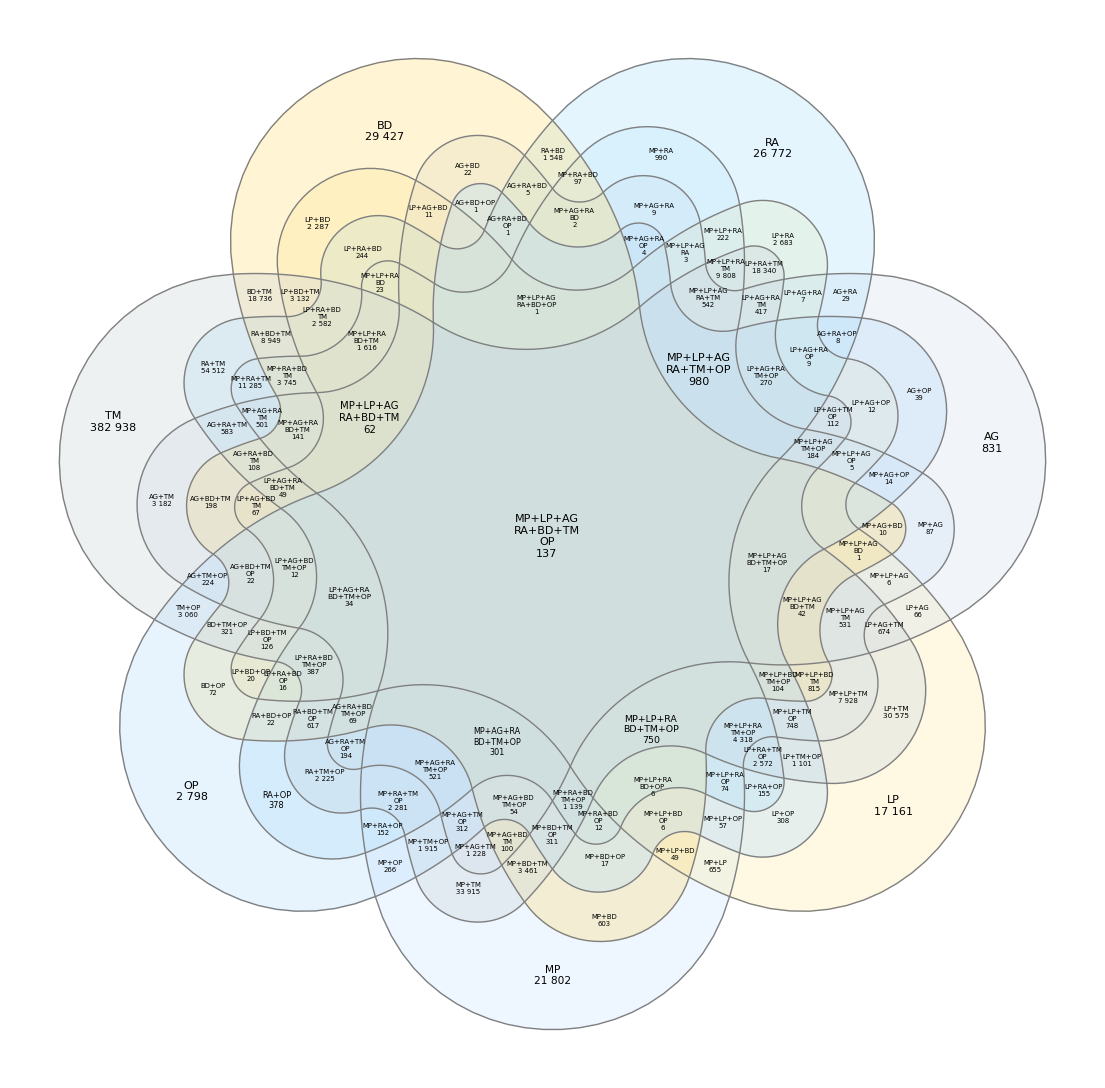

In [9]:
# =========================================
# Diagram and Visualisation
# =========================================

diagram = VennDiagram(
    7,
    """
    010000000000
    101000001000
    010100010101
    100010101010
    000001010001
    000000100000
    """,
    name="7-set SQL example"
)

fig = diagram.plot_with_values(region_counts)
fig.savefig(r"C:\Users\polina.shishkina\Desktop\venn7\venn_diagram.png", dpi=150, bbox_inches ='tight')
plt.close(fig)

## 8. Result

The file `venn_diagram.png` has been saved. It shows:

- **7 coloured petals** — each representing one marketing campaign
- **Numbers inside regions** — customer counts for each combination
- **Text labels** — readable combination names (e.g., "MP+RA+BD")

This diagram allows marketing teams to instantly see:
- Which single campaigns have the most participants
- Which pairs of campaigns overlap most strongly
- Whether there are customers in all 7 campaigns simultaneously
- Which combinations are empty or very small

**Next steps:** Import the PNG into reports, presentations, or dashboards.